<a href="https://colab.research.google.com/github/pedrosampaiom2007-gif/CP2-SERS/blob/main/Aula_APIs_Energia_Renovavel_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Avaliação — APIs de energia renovável e aprendizado de máquina

Consulte duas APIs públicas, organize os dados e resolva **duas tarefas**: classificar a fonte de empreendimentos da ANEEL e estimar a radiação solar em Petrolina (PE). Em **cada tarefa**, treine e compare **três algoritmos diferentes**. Este notebook fornece a consulta às APIs e os arquivos de dados; **você implementará a análise e os modelos**.

**Entrega:** um único link para um repositório público no GitHub com notebook executável, arquivos de dados, README e resultados. As instruções completas estão ao final e no enunciado separado.

## O que é recebido da API?

Uma requisição HTTP `GET` pede dados a uma URL. Os parâmetros identificam o recurso, o período e as variáveis. A resposta é **JSON**: um objeto com chaves e valores. Nas duas consultas desta avaliação, o acesso público **não exige login, token ou chave de API**. Se outra API exigir credenciais, não as publique no repositório.

Este código usa somente `json`, `urllib` e `csv`, bibliotecas que vêm com Python. `csv` serve apenas para exportar os dados recebidos; os imports para análise, tabelas, gráficos e ML são parte da sua implementação.

In [ ]:
import json
import urllib.parse
import urllib.request
import csv

A função a seguir monta a URL, abre a conexão, verifica o status HTTP e converte o JSON. Se houver falha na rede ou na API, exibe uma mensagem de erro.

In [ ]:
def consultar_api(endereco, parametros):
    url = endereco + "?" + urllib.parse.urlencode(parametros)
    try:
        with urllib.request.urlopen(url, timeout=30) as resposta:
            return json.load(resposta)
    except Exception as erro:
        raise RuntimeError(f"Não foi possível consultar a API: {erro}") from erro

# Tarefa 1 — Classificação (ANEEL)

**Pergunta:** a partir da potência e da localização de um empreendimento, é possível classificar sua fonte como **Solar, Eólica ou Hidráulica**?

A fonte é uma **categoria**: o problema é de classificação. O conjunto [SIGA da ANEEL](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel) registra empreendimentos em várias fases. Usamos `UFV` (solar fotovoltaica), `EOL` (eólica) e três categorias hidráulicas: `UHE`, `PCH`, `CGH`. Estas três últimas formarão uma única classe, *Hidráulica*. A tarefa trata da **categoria do cadastro**, não da quantidade de energia gerada.

### Atributos originais da resposta

| Campo da API | Significado | Uso na tarefa |
|---|---|---|
| `SigTipoGeracao` | Sigla do tipo de geração (`UFV`, `EOL`, `UHE`, `PCH`, `CGH`) | Origina o alvo `fonte`; **não entra em X** |
| `MdaPotenciaOutorgadaKw` | Potência outorgada do empreendimento, em quilowatts (kW) | Entrada `potencia_kw`; potência nominal autorizada, não energia produzida |
| `NumCoordNEmpreendimento` | Latitude aproximada do empreendimento, em graus decimais | Entrada `latitude` |
| `NumCoordEEmpreendimento` | Longitude aproximada do empreendimento, em graus decimais | Entrada `longitude` |
| `CodCEG`, `NomEmpreendimento` e campos de combustível | Código, nome e descrição associados ao empreendimento e à fonte | **Não usar como entradas**: podem revelar a classe |

A resposta CKAN contém `success` e `result`; dentro de `result`, `records` são as linhas, `fields` descrevem as colunas e `total` indica o total encontrado para o filtro. O CSV final terá **três atributos numéricos e a classe**. Quantidades consultadas têm limite por tipo e não representam a participação de cada fonte na matriz brasileira.

### 1. Consultar a ANEEL

O recurso SIGA é acessado pela API pública CKAN/DataStore. `resource_id` aponta para o conjunto; `filters` seleciona uma sigla; `limit` limita o retorno de cada pedido. Não há etapa de autenticação para esta consulta pública.

In [ ]:
URL_ANEEL = "https://dadosabertos.aneel.gov.br/api/3/action/datastore_search"
ID_RECURSO = "11ec447d-698d-4ab8-977f-b424d5deee6a"
SIGLAS = ["UFV", "EOL", "UHE", "PCH", "CGH"]
print("API ANEEL: consulta pública, sem token")

API ANEEL: consulta pública, sem token


In [ ]:
registros_aneel = []
for sigla in SIGLAS:
    parametros = {
        "resource_id": ID_RECURSO,
        "filters": json.dumps({"SigTipoGeracao": sigla}),
        "limit": 1200,
    }
    resposta = consultar_api(URL_ANEEL, parametros)
    if not resposta.get("success"):
        raise ValueError(f"Consulta da ANEEL falhou para {sigla}")
    linhas = resposta["result"]["records"]
    print(f"{sigla}: {len(linhas)} linhas recebidas")
    registros_aneel.extend(linhas)
print("Total de linhas recebidas:", len(registros_aneel))

UFV: 1200 linhas recebidas
EOL: 1200 linhas recebidas
UHE: 221 linhas recebidas
PCH: 537 linhas recebidas
CGH: 718 linhas recebidas
Total de linhas recebidas: 3876


### 2. Gerar o CSV para a tarefa

A API pode fornecer números como texto, inclusive com vírgula decimal. O tratamento abaixo converte esses valores, descarta linhas sem potência ou coordenadas e transforma as siglas em três classes. Cada linha do arquivo final representa **um empreendimento**. Confira a quantidade de exemplos por classe durante sua análise; se necessário, discuta o desequilíbrio entre classes.

In [ ]:
def numero(valor):
    texto = str(valor).strip()
    if "," in texto:
        texto = texto.replace(".", "").replace(",", ".")
    try:
        return float(texto)
    except ValueError:
        return None

fontes = {"UFV": "Solar", "EOL": "Eólica", "UHE": "Hidráulica",
          "PCH": "Hidráulica", "CGH": "Hidráulica"}
linhas_classificacao = []
for registro in registros_aneel:
    potencia = numero(registro.get("MdaPotenciaOutorgadaKw"))
    latitude = numero(registro.get("NumCoordNEmpreendimento"))
    longitude = numero(registro.get("NumCoordEEmpreendimento"))
    fonte = fontes.get(registro.get("SigTipoGeracao"))
    if fonte and all(valor is not None for valor in (potencia, latitude, longitude)):
        linhas_classificacao.append([potencia, latitude, longitude, fonte])
if len(linhas_classificacao) < 90:
    raise ValueError("Poucos registros válidos: confira a resposta da ANEEL")
print("Linhas válidas:", len(linhas_classificacao))
print("Primeiro exemplo:", linhas_classificacao[0])

Linhas válidas: 3876
Primeiro exemplo: [20.48, -10.44277778, -64.15194444, 'Solar']


In [ ]:
with open("aneel_classificacao_orange.csv", "w", newline="", encoding="utf-8-sig") as arquivo:
    escritor = csv.writer(arquivo)
    escritor.writerow(["potencia_kw", "latitude", "longitude", "fonte"])
    escritor.writerows(linhas_classificacao)
print("Salvo: aneel_classificacao_orange.csv")

Salvo: aneel_classificacao_orange.csv


### O que você deve fazer — classificação

1. Carregue o CSV, confira os tipos das colunas, as contagens por classe, valores ausentes e distribuições relevantes. Explique `X` (três entradas) e `y` (`fonte`).
2. Faça uma divisão **estratificada** de treino/teste, por exemplo 80%/20%, com semente fixa. Ajustes de escala aprendidos dos dados devem ser feitos **somente com o treino**.
3. Escolha, justifique e treine **três classificadores diferentes** usando a mesma divisão. Eles **não estão importados nem implementados** neste notebook.
4. Compare Accuracy, Precision, Recall e F1. Declare o tipo de média usado nas métricas por classe (por exemplo, `macro`) e apresente a matriz de confusão.
5. Explique qual modelo escolheria, quais classes ele mais confunde e por que potência/localização podem não bastar para uma aplicação real. Não use `SigTipoGeracao`, nomes, CEG ou descrições da fonte como entradas.

**O que registrar:** tabela comparativa dos três algoritmos, gráfico(s) ou matriz de confusão e interpretação escrita.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
# Algoritmos do sklearn para classificação
from sklearn.linear_model import LogisticRegression # Prever número regressao
from sklearn.tree import DecisionTreeClassifier # Prever classificação
from sklearn.ensemble import RandomForestClassifier # Prever classificação
from sklearn.neighbors import KNeighborsClassifier # Prever classificação
# Separação dos dados de treino e teste

from sklearn.model_selection import train_test_split

#X_train,X_test,y_train,Y_test

# treinar modelo usa o fit (X_train, Y_train)

# Métricas para classificação

from sklearn.metrics import accuracy_score # acurácia
from sklearn.metrics import confusion_matrix # identificação de onde o modelo errou
from sklearn.metrics import classification_report #Resumo de métricas

In [ ]:
dados_cp=pd.read_csv("https://raw.githubusercontent.com/prof-atritiack/CHECKPOINT_02_SERS_1CC_2SEM/refs/heads/main/aneel_classificacao_orange.csv")
dados_cp.head() # Carregando os dados

,potencia_kw,latitude,longitude,fonte
0,20.48,-10.442778,-64.151944,Solar
1,5000.00,-6.003889,-40.274722,Solar
2,12.26,-23.557778,-46.734000,Solar
3,3.00,-23.558889,-46.735000,Solar
4,1.70,-23.493819,-46.845000,Solar


In [ ]:
dados_cp.isnull().sum() # Verificando se há valores ausentes

,0
potencia_kw,0
latitude,0
longitude,0
fonte,0


In [ ]:
dados_cp.info() # Verificando o tipo de dado dos valores das colunas

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3876 entries, 0 to 3875
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   potencia_kw  3876 non-null   float64
 1   latitude     3876 non-null   float64
 2   longitude    3876 non-null   float64
 3   fonte        3876 non-null   object 
dtypes: float64(3), object(1)
memory usage: 121.3+ KB


In [ ]:
dados_cp["fonte"].unique() # Verificando os valores únicos da coluna fonte

array(['Solar', 'Eólica', 'Hidráulica'], dtype=object)

In [ ]:
dados_cp["fonte"].value_counts() # Verificando a quantidade de valores únicos da coluna fonte (target)

,count
fonte,
Hidráulica,1476
Solar,1200
Eólica,1200


In [ ]:
dados_cp.describe()# Verificando dados estatísticos

,potencia_kw,latitude,longitude
count,3.876000e+03,3876.000000,3876.000000
mean,4.201468e+04,-12.693951,-46.158299
std,3.016366e+05,9.500523,8.357453
min,1.600000e-01,-33.722806,-69.941389
25%,4.400000e+02,-21.142110,-52.561817
50%,1.268000e+04,-10.469532,-47.393697
75%,3.000000e+04,-4.127788,-41.280013
max,1.123310e+07,3.831392,0.000000


In [ ]:
dados_cp[["potencia_kw","latitude","longitude"]].value_counts()

potencia_kw  latitude    longitude 
37200.0       0.000000    0.000000     5
1000.0        0.000000    0.000000     4
30000.0      -9.531903   -40.487846    4
50400.0       0.000000    0.000000     4
2000.0        0.000000    0.000000     3
                                      ..
1250.0       -22.570464  -46.409941    1
1260.0       -21.017222  -42.440833    1
             -21.013985  -42.460709    1
             -20.865278  -42.355000    1
1200.0       -26.798889  -51.950278    1
Name: count, Length: 3848, dtype: int64

In [ ]:
dados_treino=dados_cp[["potencia_kw","latitude","longitude"]]# atributos de entrada usados pra treino

In [ ]:
x=dados_treino
y=dados_cp["fonte"]# atributo de previsão

In [ ]:
x_test,x_train,y_test,y_train=train_test_split(x,y,test_size=0.2,stratify=y,random_state=42)
#

In [ ]:
modelo_lr=LogisticRegression()#regressão logística
modelo_lr.fit(x_train,y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
modelo_knn=KNeighborsClassifier()# knn vizinhos mais próximos
modelo_knn.fit(x_train,y_train)

KNeighborsClassifier()

In [ ]:
modelo_random=RandomForestClassifier()# floresta aleatória
modelo_random.fit(x_train,y_train)#treinando o modelo

RandomForestClassifier()

In [ ]:
y_knn=modelo_knn.predict(x_test)
y_lr=modelo_lr.predict(x_test)
y_random=modelo_random.predict(x_test)

In [ ]:
acuracia_lr= accuracy_score(y_test,y_lr)
acuracia_knn= accuracy_score(y_test,y_knn)
acuracia_random= accuracy_score(y_test,y_random)
acuracia_lr,acuracia_knn,acuracia_random

(0.7132258064516129, 0.8061290322580645, 0.9551612903225807)

In [ ]:
print("--- Métricas para Regressão Logística ---")
print(classification_report(y_test, y_lr, zero_division=0))
print("Matriz de Confusão para Regressão Logística:")
print(confusion_matrix(y_test, y_lr))

print("\n--- Métricas para K-Nearest Neighbors (KNN) ---")
print(classification_report(y_test, y_knn, zero_division=0))
print("Matriz de Confusão para K-Nearest Neighbors (KNN):")
print(confusion_matrix(y_test, y_knn))

print("\n--- Métricas para Random Forest ---")
print(classification_report(y_test, y_random, zero_division=0))
print("Matriz de Confusão para Random Forest:")
print(confusion_matrix(y_test, y_random))

--- Métricas para Regressão Logística ---
              precision    recall  f1-score   support

      Eólica       0.64      0.66      0.65       960
  Hidráulica       0.75      0.80      0.78      1180
       Solar       0.74      0.65      0.70       960

    accuracy                           0.71      3100
   macro avg       0.71      0.71      0.71      3100
weighted avg       0.71      0.71      0.71      3100

Matriz de Confusão para Regressão Logística:
[[634 206 120]
 [132 949  99]
 [226 106 628]]

--- Métricas para K-Nearest Neighbors (KNN) ---
              precision    recall  f1-score   support

      Eólica       0.69      0.78      0.73       960
  Hidráulica       0.86      0.84      0.85      1180
       Solar       0.88      0.79      0.83       960

    accuracy                           0.81      3100
   macro avg       0.81      0.80      0.81      3100
weighted avg       0.81      0.81      0.81      3100

Matriz de Confusão para K-Nearest Neighbors (KNN):
[[750

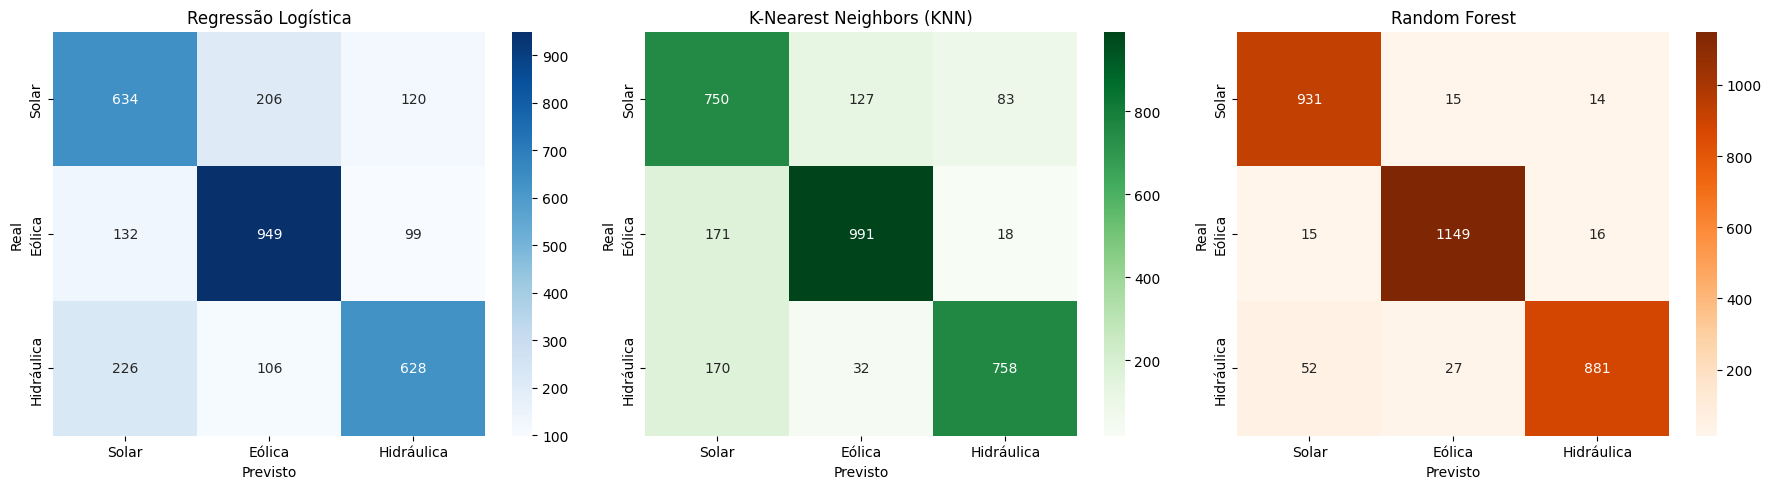

In [ ]:
plt.figure(figsize=(18, 5))

# Matriz de Confusão para Regressão Logística
plt.subplot(1, 3, 1)
sns.heatmap(confusion_matrix(y_test, y_lr), annot=True, fmt='d', cmap='Blues',
            xticklabels=y.unique(), yticklabels=y.unique())
plt.title('Regressão Logística')
plt.xlabel('Previsto')
plt.ylabel('Real')

# Matriz de Confusão para K-Nearest Neighbors (KNN)
plt.subplot(1, 3, 2)
sns.heatmap(confusion_matrix(y_test, y_knn), annot=True, fmt='d', cmap='Greens',
            xticklabels=y.unique(), yticklabels=y.unique())
plt.title('K-Nearest Neighbors (KNN)')
plt.xlabel('Previsto')
plt.ylabel('Real')

# Matriz de Confusão para Random Forest
plt.subplot(1, 3, 3)
sns.heatmap(confusion_matrix(y_test, y_random), annot=True, fmt='d', cmap='Oranges',
            xticklabels=y.unique(), yticklabels=y.unique())
plt.title('Random Forest')
plt.xlabel('Previsto')
plt.ylabel('Real')

plt.tight_layout()
plt.show()

Com base na análise, o **Random Forest** é o melhor modelo (acurácia ~0.96). Ele mais confunde a categoria Hidráulica, principalmente com Solar (52 instâncias) e Eólica (27 instâncias).

**Por que potência/localização podem não bastar para uma aplicação real:**

Embora úteis, `potencia_kw`, `latitude` e `longitude` são limitadas porque não capturam detalhes como:

1.  **Variações regionais e microclima:** Topografia, microclimas, ou recursos específicos (vento, água, sol) não são totalmente representados por coordenadas gerais.
2.  **Tecnologia e eficiência:** Diferenças na tecnologia de geração (ex: tipos de painéis solares) afetam o desempenho mas não são visíveis nos dados.
3.  **Fatores regulatórios e infraestrutura:** Licenças, leis ou proximidade com redes de transmissão são cruciais na escolha da fonte, mas ausentes nos dados.
4.  **Dados históricos de geração:** A potência outorgada é nominal; a geração real ao longo do tempo seria um preditor mais rico.

Para uma aplicação robusta, seria ideal complementar com dados mais contextuais e detalhados.

# Tarefa 2 — Regressão (Open-Meteo)

**Pergunta:** dadas as condições meteorológicas e a hora local em Petrolina (PE), qual é a radiação solar horizontal média naquela hora? A resposta é um **número**, então o problema é de regressão.

A API histórica do [Open-Meteo](https://open-meteo.com/en/docs/historical-weather-api) devolve dados horários para coordenadas e período escolhidos. Usamos **1º de abril a 30 de junho de 2025**, em horário local. São dados históricos estimados por modelos/reanálise, não leituras de um sensor particular. **Radiação em W/m² não equivale à energia em kWh nem à geração de um painel.**

### Parâmetros da requisição

| Parâmetro | Valor nesta avaliação | Significado |
|---|---|---|
| `latitude`, `longitude` | `-9.39`, `-40.50` | Coordenadas aproximadas de Petrolina (PE) |
| `start_date`, `end_date` | `2025-04-01`, `2025-06-30` | Período histórico consultado, inclusive as datas extremas |
| `timezone` | `America/Recife` | Faz `time` representar a hora local |
| `hourly` | Lista das cinco variáveis abaixo | Solicita valores horários em JSON |

### Atributos do conjunto de dados

| Campo da API → CSV | Significado e unidade | Uso na tarefa |
|---|---|---|
| `time` → `data_hora` | Data e hora local de cada registro | Ordenar e separar por tempo; não é entrada em X |
| `temperature_2m` → `temperatura_c` | Temperatura do ar a 2 m, em °C | Entrada |
| `relative_humidity_2m` → `umidade_pct` | Umidade relativa a 2 m, em % | Entrada |
| `cloud_cover` → `nuvens_pct` | Cobertura total de nuvens, em % | Entrada |
| `wind_speed_10m` → `vento_kmh` | Velocidade do vento a 10 m, em km/h | Entrada |
| `time` → `hora` | Hora local extraída da data, de 7 a 17 nesta amostra | Entrada |
| `shortwave_radiation` → `radiacao_w_m2` | Radiação solar global horizontal média da hora anterior, em W/m² | Alvo numérico `y`; **não entra em X** |

A resposta inclui `hourly` (listas dos valores, alinhadas por índice), `hourly_units` (unidades) e metadados da localização. Cada linha do CSV final representa **uma hora entre 7h e 17h**; esse recorte reduz o domínio de horas noturnas, mas não remove a importância da hora para a previsão.

### 3. Consultar o histórico meteorológico

A chamada usa GET, sem cadastro ou chave para esta consulta pública de uso educacional. Se `hourly` faltar, verifique datas e parâmetros.

In [ ]:
URL_METEO = "https://archive-api.open-meteo.com/v1/archive"
parametros_meteo = {
    "latitude": -9.39,
    "longitude": -40.50,
    "start_date": "2025-04-01",
    "end_date": "2025-06-30",
    "timezone": "America/Recife",
    "hourly": ",".join(["temperature_2m", "relative_humidity_2m",
                         "cloud_cover", "wind_speed_10m", "shortwave_radiation"]),
}
print("Open-Meteo: consulta pública, sem token")

Open-Meteo: consulta pública, sem token


In [ ]:
resposta_meteo = consultar_api(URL_METEO, parametros_meteo)
if "hourly" not in resposta_meteo:
    raise ValueError("Resposta sem a seção hourly")
horas_api = resposta_meteo["hourly"]
print("Campos recebidos:", list(horas_api))
print("Unidades informadas pela API:", resposta_meteo.get("hourly_units", {}))
print("Quantidade de horários:", len(horas_api["time"]))

Campos recebidos: ['time', 'temperature_2m', 'relative_humidity_2m', 'cloud_cover', 'wind_speed_10m', 'shortwave_radiation']
Unidades informadas pela API: {'time': 'iso8601', 'temperature_2m': '°C', 'relative_humidity_2m': '%', 'cloud_cover': '%', 'wind_speed_10m': 'km/h', 'shortwave_radiation': 'W/m²'}
Quantidade de horários: 2184


### 4. Gerar o CSV horário

As listas de `hourly` são alinhadas: o índice 0 de cada variável se refere ao índice 0 de `time`. Percorremos esses índices, mantemos as horas de 7h a 17h e descartamos linhas com valores ausentes. A data permanece ordenada para facilitar uma avaliação temporal.

In [ ]:
nomes_api = ["temperature_2m", "relative_humidity_2m", "cloud_cover",
             "wind_speed_10m", "shortwave_radiation"]
linhas_regressao = []
for indice, data_hora in enumerate(horas_api["time"]):
    hora = int(data_hora[11:13])
    valores = [horas_api[nome][indice] for nome in nomes_api]
    if 7 <= hora <= 17 and all(valor is not None for valor in valores):
        linhas_regressao.append([data_hora, *valores[:4], hora, valores[4]])
if len(linhas_regressao) < 100:
    raise ValueError("Poucos horários válidos: confira a resposta do Open-Meteo")
print("Horas válidas:", len(linhas_regressao))
print("Primeiro exemplo:", linhas_regressao[0])

Horas válidas: 1001
Primeiro exemplo: ['2025-04-01T07:00', 25.3, 74, 100, 17.7, 7, 116.0]


In [ ]:
with open("meteo_regressao_orange.csv", "w", newline="", encoding="utf-8-sig") as arquivo:
    escritor = csv.writer(arquivo)
    escritor.writerow(["data_hora", "temperatura_c", "umidade_pct",
                       "nuvens_pct", "vento_kmh", "hora", "radiacao_w_m2"])
    escritor.writerows(linhas_regressao)
print("Salvo: meteo_regressao_orange.csv")

Salvo: meteo_regressao_orange.csv


### O que você deve fazer — regressão

1. Carregue o CSV, explique as colunas, examine valores ausentes e apresente ao menos uma visualização. Defina `X` (cinco entradas) e `y` (`radiacao_w_m2`).
2. Mantenha as linhas em ordem de `data_hora`: use aproximadamente **80% das primeiras horas para treino** e as 20% finais para teste. Evite embaralhar as horas. Ajuste transformações apenas com o treino.
3. Escolha, justifique e treine **três algoritmos de regressão diferentes** com a mesma divisão. Os imports e a implementação são sua responsabilidade.
4. Compare **MAE** (W/m²), **MSE** ((W/m²)²) e **R²**; faça um gráfico de valores reais × previstos de pelo menos um modelo.
5. Interprete os erros, discuta o peso da hora e explique por que essa estimativa da radiação **não prevê automaticamente a energia produzida** por um sistema fotovoltaico.

**O que registrar:** tabela comparativa dos três algoritmos, gráfico e interpretação escrita. Nenhum valor de `radiacao_w_m2` deve ser usado para criar uma entrada do mesmo registro.

In [ ]:
dados_regressao = pd.read_csv('meteo_regressao_orange.csv')
dados_regressao.head()

,data_hora,temperatura_c,umidade_pct,nuvens_pct,vento_kmh,hora,radiacao_w_m2
0,2025-04-01T07:00,25.3,74,100,17.7,7,116.0
1,2025-04-01T08:00,26.5,66,100,18.1,8,269.0
2,2025-04-01T09:00,28.4,55,97,18.0,9,529.0
3,2025-04-01T10:00,30.8,44,21,18.4,10,797.0
4,2025-04-01T11:00,32.7,36,26,20.1,11,880.0


In [ ]:
dados_regressao = pd.read_csv('meteo_regressao_orange.csv')
print(dados_regressao.columns.tolist())
print(dados_regressao.shape)

['data_hora', 'temperatura_c', 'umidade_pct', 'nuvens_pct', 'vento_kmh', 'hora', 'radiacao_w_m2']
(1001, 7)


In [ ]:
dados_regressao['data_hora'] = pd.to_datetime(dados_regressao['data_hora'])
dados_regressao = dados_regressao.sort_values('data_hora').reset_index(drop=True)

print(dados_regressao.shape)
print(dados_regressao.dtypes)
print(dados_regressao.isna().sum())
dados_regressao.describe()

(1001, 7)
data_hora        datetime64[ns]
temperatura_c           float64
umidade_pct               int64
nuvens_pct                int64
vento_kmh               float64
hora                      int64
radiacao_w_m2           float64
dtype: object
data_hora        0
temperatura_c    0
umidade_pct      0
nuvens_pct       0
vento_kmh        0
hora             0
radiacao_w_m2    0
dtype: int64


,data_hora,temperatura_c,umidade_pct,nuvens_pct,vento_kmh,hora,radiacao_w_m2
count,1001,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000
mean,2025-05-16 11:59:59.999999744,28.885914,50.544456,55.108891,15.465435,12.000000,472.854146
min,2025-04-01 07:00:00,19.500000,21.000000,0.000000,2.300000,7.000000,13.000000
25%,2025-04-23 15:00:00,26.300000,38.000000,19.000000,12.200000,9.000000,250.000000
50%,2025-05-16 12:00:00,29.100000,49.000000,54.000000,15.400000,12.000000,466.000000
75%,2025-06-08 09:00:00,31.700000,61.000000,98.000000,19.000000,15.000000,696.000000
max,2025-06-30 17:00:00,36.100000,95.000000,100.000000,30.100000,17.000000,1002.000000
std,NaN,3.656514,15.913965,37.851461,4.923631,3.163858,256.368950


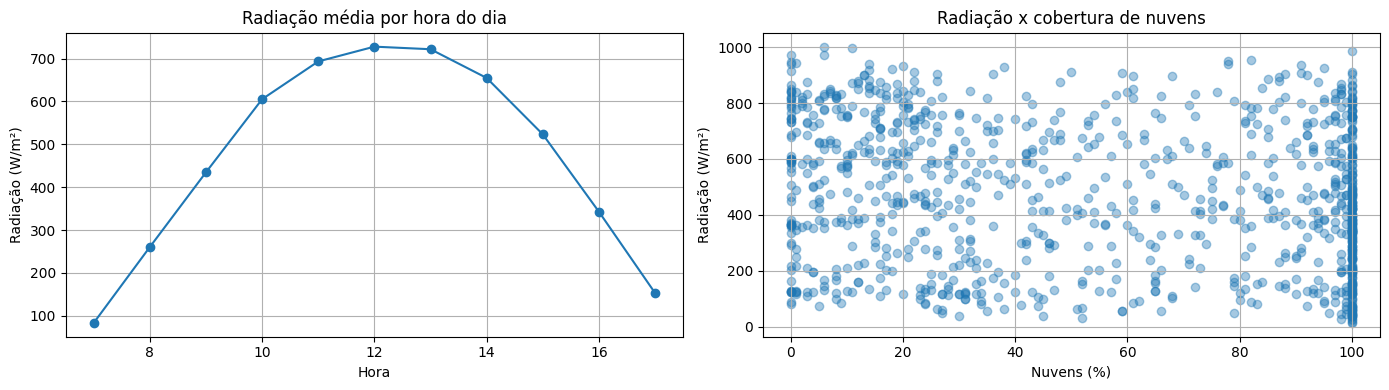

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

media_hora = dados_regressao.groupby('hora')['radiacao_w_m2'].mean()
axes[0].plot(media_hora.index, media_hora.values, marker='o')
axes[0].set_title('Radiação média por hora do dia')
axes[0].set_xlabel('Hora')
axes[0].set_ylabel('Radiação (W/m²)')
axes[0].grid(True)

axes[1].scatter(dados_regressao['nuvens_pct'], dados_regressao['radiacao_w_m2'], alpha=0.4)
axes[1].set_title('Radiação x cobertura de nuvens')
axes[1].set_xlabel('Nuvens (%)')
axes[1].set_ylabel('Radiação (W/m²)')
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
colunas_x = ['temperatura_c', 'umidade_pct', 'nuvens_pct', 'vento_kmh', 'hora']
X = dados_regressao[colunas_x]
y = dados_regressao['radiacao_w_m2']

corte = int(len(dados_regressao) * 0.8)

X_treino, X_teste = X.iloc[:corte], X.iloc[corte:]
y_treino, y_teste = y.iloc[:corte], y.iloc[corte:]

print('Treino:', dados_regressao['data_hora'].iloc[0], '->', dados_regressao['data_hora'].iloc[corte - 1])
print('Teste :', dados_regressao['data_hora'].iloc[corte], '->', dados_regressao['data_hora'].iloc[-1])
print(X_treino.shape, X_teste.shape)

Treino: 2025-04-01 07:00:00 -> 2025-06-12 14:00:00
Teste : 2025-06-12 15:00:00 -> 2025-06-30 17:00:00
(800, 5) (201, 5)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_treino_esc = scaler.fit_transform(X_treino)
X_teste_esc = scaler.transform(X_teste)

In [ ]:
modelos = {
    'Regressão Linear': (LinearRegression(), True),
    'Árvore de Decisão': (DecisionTreeRegressor(max_depth=6, random_state=42), False),
    'Random Forest': (RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42), False),
}

resultados = []
previsoes = {}

for nome, (modelo, usa_escala) in modelos.items():
    Xtr = X_treino_esc if usa_escala else X_treino
    Xte = X_teste_esc if usa_escala else X_teste

    modelo.fit(Xtr, y_treino)
    y_pred = modelo.predict(Xte)
    previsoes[nome] = y_pred

    resultados.append({
        'Modelo': nome,
        'MAE (W/m²)': mean_absolute_error(y_teste, y_pred),
        'MSE ((W/m²)²)': mean_squared_error(y_teste, y_pred),
        'R²': r2_score(y_teste, y_pred),
    })

tabela = pd.DataFrame(resultados).set_index('Modelo').round(3)
tabela

,MAE (W/m²),MSE ((W/m²)²),R²
Modelo,,,
Regressão Linear,145.205,30034.201,0.360
Árvore de Decisão,90.938,15127.027,0.678
Random Forest,67.090,7393.646,0.842


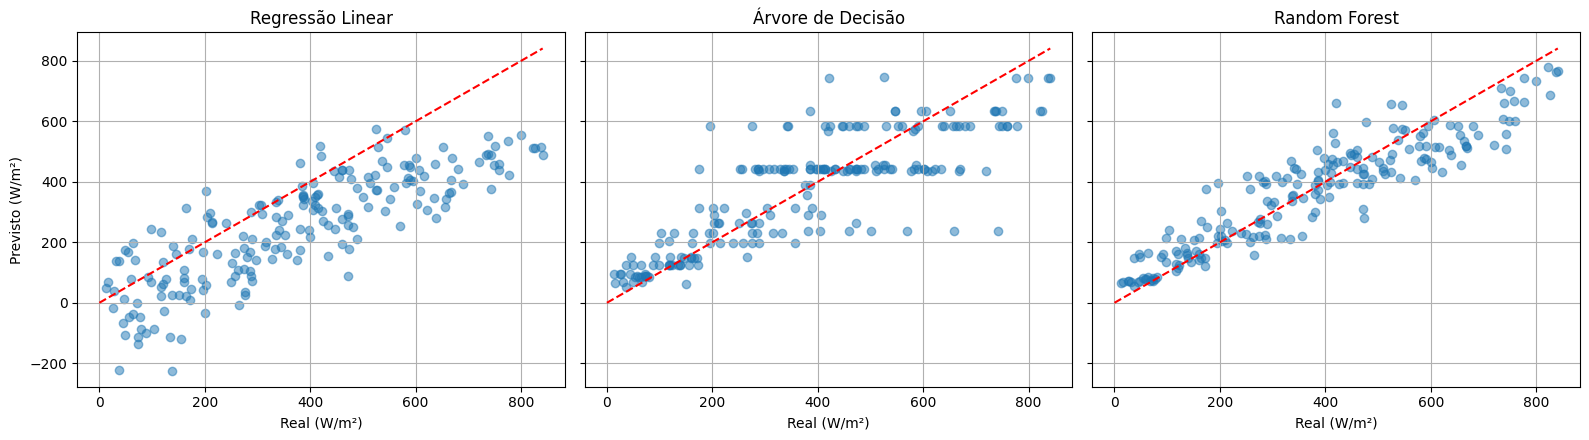

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharex=True, sharey=True)
lim = [min(y_teste.min(), 0), y_teste.max()]

for ax, (nome, y_pred) in zip(axes, previsoes.items()):
    ax.scatter(y_teste, y_pred, alpha=0.5)
    ax.plot(lim, lim, 'r--')
    ax.set_title(nome)
    ax.set_xlabel('Real (W/m²)')
    ax.grid(True)

axes[0].set_ylabel('Previsto (W/m²)')
plt.tight_layout()
plt.show()

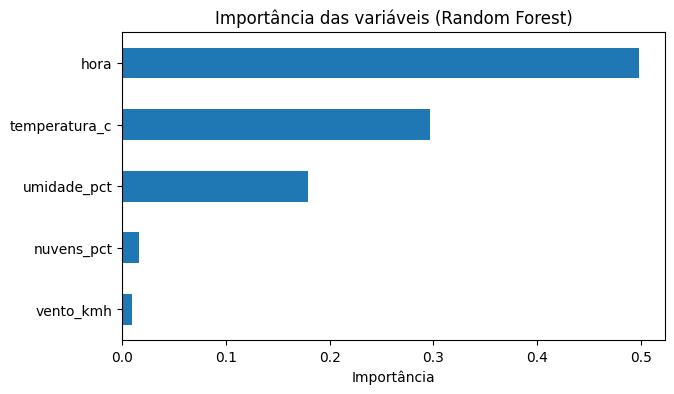

Coeficientes (variáveis padronizadas):
temperatura_c    348.554
umidade_pct       21.940
nuvens_pct        -9.717
vento_kmh         46.762
hora            -201.441
dtype: float64


In [ ]:
rf = modelos['Random Forest'][0]
importancias = pd.Series(rf.feature_importances_, index=colunas_x).sort_values()

importancias.plot(kind='barh', figsize=(7, 4), title='Importância das variáveis (Random Forest)')
plt.xlabel('Importância')
plt.show()

coef = pd.Series(modelos['Regressão Linear'][0].coef_, index=colunas_x)
print('Coeficientes (variáveis padronizadas):')
print(coef.round(3))

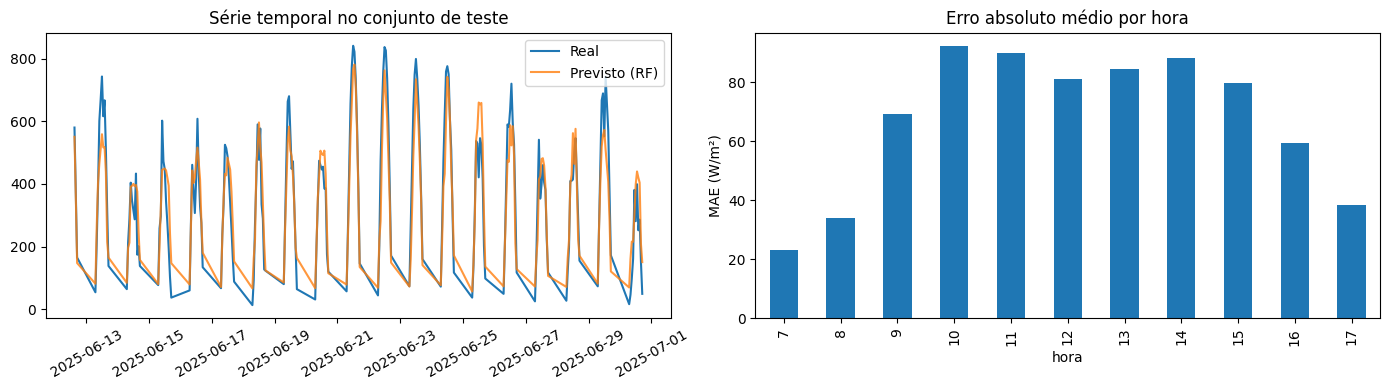

In [ ]:
y_pred_rf = previsoes['Random Forest']
teste_df = dados_regressao.iloc[corte:].copy()
teste_df['erro_abs'] = np.abs(y_teste.values - y_pred_rf)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(teste_df['data_hora'], y_teste.values, label='Real')
axes[0].plot(teste_df['data_hora'], y_pred_rf, label='Previsto (RF)', alpha=0.8)
axes[0].set_title('Série temporal no conjunto de teste')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=30)

teste_df.groupby('hora')['erro_abs'].mean().plot(kind='bar', ax=axes[1], title='Erro absoluto médio por hora')
axes[1].set_ylabel('MAE (W/m²)')

plt.tight_layout()
plt.show()

Interpretação dos erros

O Random Forest foi o modelo com menor erro no conjunto de teste, com MAE de 67,09 W/m², MSE de 7393,65 (W/m²)² e R² de 0,842. Como a radiação média da base é de cerca de 473 W/m², esse erro médio representa aproximadamente 14% do valor médio. A árvore de decisão errou em média 90,94 W/m² (cerca de 19%), com R² de 0,678. A regressão linear foi a pior, com MAE de 145,21 W/m² (cerca de 31%) e R² de 0,360, ou seja, explicou só 36% da variação da radiação.

A diferença entre os modelos mostra que a relação entre as variáveis e a radiação não é linear. A radiação sobe de manhã, chega ao máximo perto do meio-dia e cai à tarde, e uma reta não representa essa curva usando a coluna hora. A árvore e o Random Forest dividem os dados em faixas de hora e de nuvens, então conseguem seguir esse formato. O Random Forest ficou melhor que a árvore sozinha porque faz a média de 200 árvores, o que reduz o erro causado por detalhes específicos do treino.

O MSE é bem maior que o MAE porque os erros são elevados ao quadrado, então os erros grandes pesam mais. Tirando a raiz, o erro do Random Forest é de cerca de 86 W/m², acima do MAE de 67 W/m². Isso indica que o modelo erra pouco na maioria das horas, mas tem alguns erros maiores. Na regressão linear acontece o mesmo, com raiz do MSE de cerca de 173 W/m² contra MAE de 145 W/m².

No gráfico de erro médio por hora, o erro foi maior em torno das 10 e menor no começo da manhã e no fim da tarde. Isso faz sentido porque nas horas de pico a radiação é alta e varia bastante dependendo das nuvens, enquanto às 7h e às 17h os valores são baixos e variam menos. No gráfico real × previsto, o Random Forest ficou mais perto da linha tracejada, com os pontos mais concentrados. A regressão linear formou uma nuvem bem aberta e chegou a prever valores negativos, o que não faz sentido físico. A árvore de decisão formou faixas horizontais, repetindo o mesmo valor previsto para horas com radiação real diferente, porque cada folha prevê um valor fixo.

Como o teste usa os últimos dias do período (12/06 a 30/06), o modelo foi avaliado em dados que ele não viu, o que torna o resultado mais próximo de um uso real do que um embaralhamento aleatório.

Peso da hora

No Random Forest, a variável mais importante foi hora, e a hora ficou em 1 lugar. Isso faz sentido porque a radiação depende diretamente da posição do sol: é baixa às 7h e às 17h e máxima perto do meio-dia, mesmo com condições de tempo parecidas. A hora funciona como um indicador de em que ponto do dia o sol está.

As outras variáveis explicam as diferenças entre dias na mesma hora. A cobertura de nuvens reduz a radiação que chega ao solo, então um meio-dia nublado tem valores bem menores que um meio-dia de céu limpo. Temperatura e umidade também aparecem no modelo, mas parte do efeito delas está ligada ao horário e ao céu limpo ou nublado, então é difícil separar o que é causa e o que é só correlação.

Por que a radiação estimada não prevê automaticamente a energia produzida

O modelo estima a radiação solar que chega por metro quadrado (W/m²), mas isso não é a energia gerada por um sistema fotovoltaico. Para chegar na energia, ainda é preciso considerar:

Área e eficiência dos painéis: a energia depende de quantos metros quadrados de painel existem e de qual fração da radiação cada painel converte em eletricidade.
Temperatura do painel: painéis mais quentes perdem eficiência, e a temperatura do ar da base não é a temperatura da superfície do painel.
Inclinação e orientação: a radiação medida não é necessariamente a que chega na superfície inclinada do painel.
Sujeira e sombreamento: poeira, folhas ou sombra de prédios e árvores reduzem o que o painel recebe.
Perdas no sistema: inversor, cabos e conexões perdem parte da energia no caminho.
Tempo: radiação é potência por área (W/m²), e energia é essa potência acumulada ao longo do tempo (Wh), então seria preciso integrar no tempo.

Além disso, o modelo tem erro (cerca de 67 W/m² em média no melhor caso), e esse erro se propagaria para qualquer estimativa de energia. Por isso, o resultado serve como estimativa do recurso solar disponível e seria apenas uma das entradas de um modelo de geração de energia, não a resposta final.

# Entrega pelo GitHub

Envie **apenas o link do repositório público**. Organize-o com:

- `README.md` contendo objetivo, fontes e período dos dados, instruções para executar o notebook e resumo dos resultados;
- notebook `.ipynb` com a consulta às APIs, sua análise, os **três classificadores e os três regressores**, todos os imports necessários adicionados por você e conclusões em Markdown;
- os dois CSVs gerados (ou instruções completas e testadas para reproduzi-los) e eventuais figuras utilizadas.

Verifique se o notebook roda **na ordem das células** a partir de um ambiente limpo. Não inclua senhas, tokens ou arquivos sem relação com a avaliação. A banca deve conseguir encontrar as seis comparações e as respostas às duas tarefas sem procurar uma agulha no palheiro.

### Fontes

- [ANEEL — SIGA](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel)
- [ANEEL — recurso e campos usados](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel/resource/11ec447d-698d-4ab8-977f-b424d5deee6a)
- [Open-Meteo — histórico e unidades](https://open-meteo.com/en/docs/historical-weather-api)